# 01 · Calidad de datos e imputación

**Proyecto:** Operación e integridad tarifaria de los taxis amarillos de Nueva York (enero de 2017)

**Objetivo del notebook:** diagnosticar los problemas de calidad del registro de viajes, decidir un tratamiento para cada uno y construir la base analítica que usan el resto del proyecto y el tablero.

**Fuente:** NYC Taxi & Limousine Commission, *Yellow Taxi Trip Records* (9,710,820 viajes) y *Taxi Zone Lookup*.

Este notebook reemplaza las secciones de limpieza (A) e imputación (E) del proyecto del curso. Las reglas viven en `src/nyc_taxi_ops/calidad.py` y `src/nyc_taxi_ops/imputacion.py`; aquí se muestra la evidencia que sustenta cada una.

| Sección | Contenido |
|---|---|
| 1 | Carga y unión con el catálogo de zonas |
| 2 | Reglas de calidad y tratamiento por métrica |
| 3 | Imputación de la distancia faltante |
| 4 | Base analítica resultante |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nyc_taxi_ops import agregados, auditoria, calidad, config, datos, graficos, imputacion, pipeline

graficos.estilo()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:,.2f}".format)

## 1. Carga

`cargar_viajes` lee solo las columnas útiles con tipos compactos y deriva la duración, la hora, el día de la semana, el tipo de día (laborable o fin de semana/festivo) y la franja horaria. Las zonas 264 y 265, que en el catálogo de la TLC traen campos vacíos, reciben una categoría explícita.

In [2]:
viajes = datos.cargar_viajes()
zonas = datos.cargar_zonas()
viajes = datos.unir_zonas(viajes, zonas)

print(f"Viajes           : {len(viajes):,}")
print(f"Columnas         : {viajes.shape[1]}")
print(f"Memoria          : {viajes.memory_usage(deep=True).sum() / 1e6:,.0f} MB")
print(f"Rango de recogida: {viajes['tpep_pickup_datetime'].min()} → {viajes['tpep_pickup_datetime'].max()}")
zonas.tail(3)

Viajes           : 9,710,820
Columnas         : 26
Memoria          : 845 MB
Rango de recogida: 2017-01-01 00:00:00 → 2017-01-31 23:59:59


,LocationID,distrito,zona,tipo_servicio
262,263,Manhattan,Yorkville West,Yellow Zone
263,264,Desconocido,Zona desconocida,Desconocido
264,265,Fuera de NYC,Fuera de NYC,Fuera de NYC


## 2. Reglas de calidad

Cada regla genera una columna `q_*`. El tratamiento se decide **por métrica** y no por fila: un viaje cuya hora de llegada está corrupta sigue siendo un viaje válido para contar demanda, pero no para medir duración o velocidad. Las máscaras `valido_demanda`, `valido_ingreso` y `valido_tiempo` resumen esa decisión.

In [3]:
viajes = calidad.marcar_calidad(viajes)
calidad.resumen_calidad(viajes)[["regla", "viajes", "pct", "tratamiento"]]

,regla,viajes,pct,tratamiento
0,Cargo anulado (par cargo + reverso),9059,0.09,Excluir
1,Registro duplicado,29,0.00,Excluir (se conserva uno)
2,Duración ≤ 0,9343,0.10,Excluir
3,Viaje no realizado probable,19012,0.20,Excluir
4,Duración o velocidad imposible,94505,0.97,Excluir solo de métricas de tiempo
5,"Monto implausible, mayor a $1,000",10,0.00,Excluir de métricas de ingreso
6,Distancia no registrada en viaje taximetrado,6964,0.07,Imputar
7,Distancia no registrada en tarifa no taximetrada,22234,0.23,Excluir de métricas por milla
8,Número de pasajeros 0 o mayor a 6,605,0.01,Marcar como faltante
9,Zona desconocida o fuera de NYC (264 y 265),197915,2.04,Conservar con categoría explícita


### 2.1 Los "duplicados lógicos" son anulaciones

El proyecto del curso encontró 4,544 viajes con la misma clave (proveedor, horas de recogida y llegada, origen y destino) y los trató como errores de captura. Al revisar los montos de cada grupo aparece otra explicación: una fila con el cobro y otra con los mismos montos en negativo.

In [4]:
clave = calidad.CLAVE_VIAJE
grupos = viajes.loc[viajes.duplicated(clave, keep=False)]
columnas = clave[1:3] + ["VendorID", "payment_type", "fare_amount", "total_amount"]
con_negativo = grupos.groupby(clave)["total_amount"].transform("min") < 0
grupos.loc[con_negativo].sort_values(clave).head(6)[columnas]

,tpep_pickup_datetime,tpep_dropoff_datetime,VendorID,payment_type,fare_amount,total_amount
17493,2017-01-01 00:11:22,2017-01-01 00:14:25,2,3,-4.00,-5.30
17494,2017-01-01 00:11:22,2017-01-01 00:14:25,2,2,4.00,5.30
4721,2017-01-01 00:17:26,2017-01-01 00:20:12,2,4,-52.25,-53.05
4722,2017-01-01 00:17:26,2017-01-01 00:20:12,2,2,52.25,53.05
999,2017-01-01 00:23:06,2017-01-01 00:25:54,2,4,-4.50,-5.80
1000,2017-01-01 00:23:06,2017-01-01 00:25:54,2,2,4.50,5.80


In [5]:
signo = np.sign(grupos["total_amount"])
por_grupo = grupos.assign(pos=signo > 0, neg=signo < 0).groupby(clave).agg(
    filas=("pos", "size"), positivos=("pos", "sum"), negativos=("neg", "sum"), neto=("total_amount", "sum")
)
print("Composición de los grupos (positivos, negativos):")
print(por_grupo[["positivos", "negativos"]].value_counts().to_string())
print(f"\nGrupos cuyo neto es $0: {(por_grupo['neto'].abs() < 0.01).mean():.1%}")

reversos = viajes.loc[viajes["q_anulacion"] & (viajes["total_amount"] < 0)]
print("\nProveedor de las filas anuladas:", viajes.loc[viajes["q_anulacion"], "VendorID"].map(config.PROVEEDORES).value_counts().to_dict())
print("Forma de pago del reverso:", reversos["payment_type"].map(config.FORMAS_PAGO).value_counts().to_dict())

Composición de los grupos (positivos, negativos):
positivos  negativos
1          1            4513
2          0              29
0          1               2

Grupos cuyo neto es $0: 99.3%

Proveedor de las filas anuladas: {'VeriFone': 9059}
Forma de pago del reverso: {'Sin cargo': 2912, 'Disputa': 1534, 'Efectivo': 93, 'Tarjeta': 5}


### Lectura

De entrada, la revisión de los montos dentro de cada grupo permitió replantear la lectura que se había hecho en el proyecto del curso, ya que de los 4,544 grupos que comparten la misma clave de viaje, 4,513 están conformados por una fila con el cobro y otra con los mismos montos en negativo, y en el 99.3% de los grupos la suma es exactamente $0. Teniendo esto en cuenta, estos registros no corresponden a un error de captura, sino a anulaciones, es decir, a un cargo que el sistema reversó después de haberlo registrado.

Por otro lado, el patrón se concentra por completo en VeriFone, y en la fila del reverso predominan las formas de pago "Sin cargo" (2,912) y "Disputa" (1,534), lo cual es coherente con viajes que no se cobraron o cuyo cobro fue objetado por el pasajero. A partir de lo anterior, la decisión de excluir ambas filas se mantiene, pero con una justificación distinta a la del curso: no se trata de viajes duplicados, sino de servicios cuyo cobro neto fue cero y que, de conservarse la fila positiva, inflarían tanto el conteo de viajes como el ingreso. Finalmente, los 29 grupos con dos filas positivas sí se tratan como duplicados, por lo que en ese caso se conserva un solo registro.

### 2.2 Duración: el medidor que no se cierra

Las duraciones extremas no se reparten a lo largo de una cola continua: se acumulan justo por debajo de 24 horas, lo que corresponde a un taxímetro que se cerró al día siguiente. Por eso el umbral de 3 horas se usa para excluir el viaje de las métricas de tiempo, pero no de la demanda.

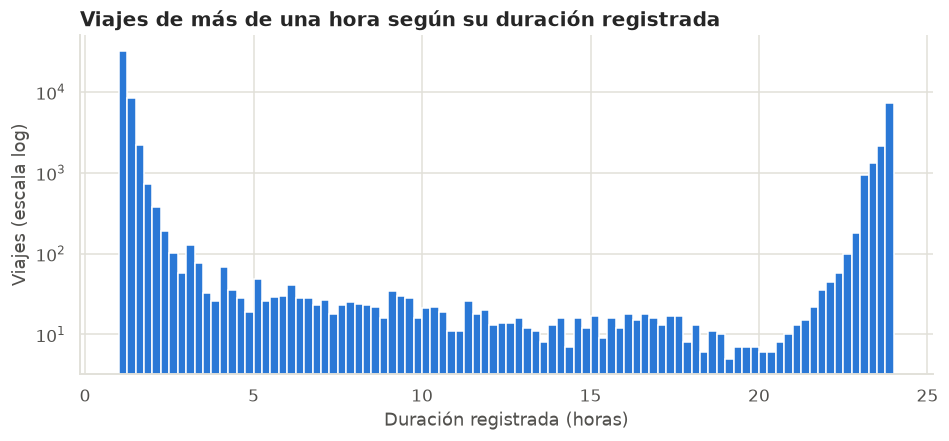

Duración >  1.0 h:  58,250
Duración >  3.0 h:  13,715
Duración > 23.0 h:  11,723


In [6]:
larga = viajes.loc[viajes["duracion_min"] > 60, "duracion_min"] / 60
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(larga, bins=np.arange(1, 24.25, 0.25), color=graficos.AZUL)
ax.set_yscale("log")
ax.set_xlabel("Duración registrada (horas)")
ax.set_ylabel("Viajes (escala log)")
ax.set_title("Viajes de más de una hora según su duración registrada")
graficos.guardar(fig, "01_duraciones_largas.png")
plt.show()

for umbral in (60, 180, 23 * 60):
    print(f"Duración > {umbral / 60:>4.1f} h: {(viajes['duracion_min'] > umbral).sum():>7,}")

### Lectura

En lo que concierne a la duración, la distribución de los viajes de más de una hora no presenta una cola que decrece de forma continua, como se esperaría de trayectos largos pero legítimos, sino dos comportamientos diferenciados: por un lado, una caída pronunciada durante las primeras horas y, por otro lado, una acumulación marcada justo antes de las 24 horas, donde se concentran 11,723 viajes con una duración superior a 23 horas. Este patrón es consistente con un taxímetro que no se cerró al terminar el viaje y que registró la llegada al día siguiente, por lo que la duración de estos registros no refleja el tiempo real del trayecto.

Teniendo en cuenta lo previamente mencionado, se decidió no eliminar estos viajes, ya que la hora de recogida sigue siendo válida y el servicio efectivamente ocurrió, pero sí excluirlos de las métricas que dependen del tiempo, como la duración, la velocidad y el ingreso por hora de servicio. Cabe señalar que el umbral de 3 horas deja por fuera 13,715 viajes, de los cuales el 85.5% corresponde a este caso, lo que lo convierte en un criterio conservador frente a la alternativa de eliminar el registro completo.

### 2.3 Distancia 0 con cobro: tres situaciones distintas

El curso reportó 57,169 viajes con distancia 0 y tarifa positiva como una sola limitación. Al cruzarlos con la duración, el código de tarifa y la zona se separan en tres casos con tratamientos diferentes:

- **Viaje no realizado probable:** menos de un minuto y cobro cercano al banderazo. Se excluye.
- **Distancia no registrada en un viaje taximetrado:** tarifa estándar con cobro y duración positivos. Se imputa.
- **Distancia que no aplica:** tarifas negociadas, planas o con zona desconocida, donde el taxímetro no mide distancia. Se excluye solo de las métricas por milla.

In [7]:
distancia_cero = (viajes["trip_distance"] == 0) & (viajes["fare_amount"] > 0)
caso = np.select(
    [viajes["q_no_realizado"], viajes["q_distancia_imputable"], viajes["q_distancia_no_aplica"]],
    ["No realizado", "Imputable", "No aplica"],
    default="Otra exclusión",
)
tabla = pd.crosstab(
    viajes.loc[distancia_cero, "RatecodeID"].map(config.CODIGOS_TARIFA),
    pd.Series(caso, index=viajes.index)[distancia_cero],
    margins=True, margins_name="Total",
)
tabla

col_0,Imputable,No aplica,No realizado,Otra exclusión,Total
RatecodeID,,,,,
Código inválido,0,0,1,154,155
Estándar,6964,1313,18264,8062,34603
JFK (tarifa plana),0,6471,0,522,6993
Nassau / Westchester,0,13,56,20,89
Negociada,0,13745,473,300,14518
Newark,0,677,0,75,752
Viaje compartido,0,15,39,5,59
Total,6964,22234,18833,9138,57169


### Lectura

Con respecto a los 57,169 viajes con distancia igual a cero y tarifa positiva, que en el proyecto del curso se documentaron como una sola limitación, el cruce con el código de tarifa, la duración y el cobro permitió separarlos en situaciones con causas distintas. En primer lugar, 18,833 corresponden a viajes que duraron menos de un minuto y cuyo cobro no supera los $3, lo que indica que el taxímetro se activó sin que hubiera un trayecto; en segundo lugar, 22,234 se concentran en tarifas que no dependen del taxímetro, principalmente la tarifa negociada (13,745) y la tarifa plana de JFK (6,471), donde la distancia simplemente no se mide; y en tercer lugar, 6,964 son viajes con tarifa estándar, cobro y duración positivos, en los que el trayecto existió pero la distancia no quedó registrada.

A partir de esta separación, cada grupo recibió un tratamiento acorde con su causa: los viajes no realizados se excluyen, los de tarifa no taximetrada se conservan pero quedan por fuera de las métricas por milla, y únicamente los viajes taximetrados sin distancia pasan a imputación, ya que son el único caso en el que existe información suficiente para estimar el valor faltante. Finalmente, los 9,138 viajes restantes ya habían sido excluidos por otras reglas, como las anulaciones o las duraciones menores o iguales a cero.

## 3. Imputación de la distancia

La distancia faltante de los viajes taximetrados es un faltante real, a diferencia del faltante artificial que se simuló en el curso sobre la duración (que nunca falta, porque se calcula con las marcas de tiempo). Se comparan tres estrategias ocultando a propósito el 20% de las distancias de una muestra de 300,000 viajes estándar válidos y midiendo el error contra el valor verdadero:

1. **Mediana global** (estadística, sin información adicional).
2. **Mediana por par de zonas** (estadística condicional).
3. **Regresión de la distancia sobre la tarifa y la duración** (basada en modelo). El tarifario hace que la tarifa sea casi una función determinística de la distancia recorrida y del tiempo en tráfico lento, así que esta estrategia invierte esa relación.

In [8]:
comparacion, estimados = imputacion.comparar_metodos(viajes)
print(f"Entrenamiento: {comparacion.attrs['n_entrenamiento']:,} | prueba: {comparacion.attrs['n_prueba']:,}")
comparacion

Entrenamiento: 240,031 | prueba: 59,969


,metodo,mae,mediana_error_abs,rmse,std_estimada,std_real
0,Mediana global,1.53,0.78,2.86,0.00,2.71
1,Mediana por par de zonas,0.47,0.27,1.20,2.46,2.71
2,Regresión tarifa + duración,0.19,0.13,0.30,2.68,2.71


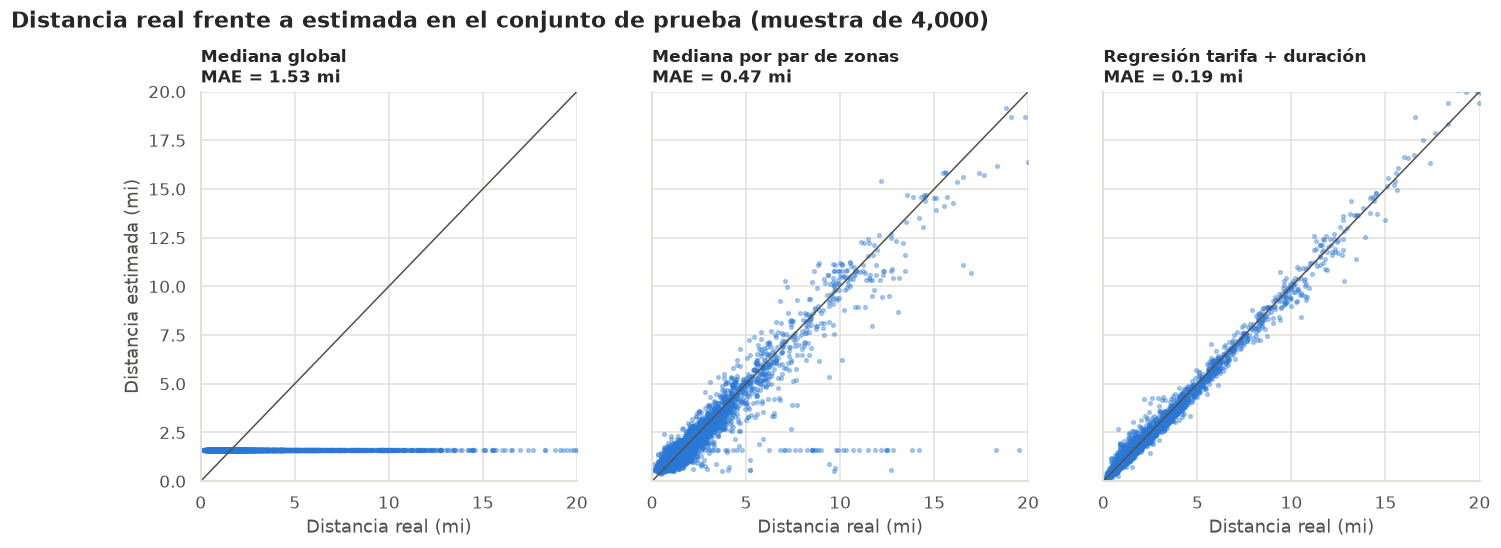

In [9]:
rng = np.random.default_rng(config.SEMILLA)
idx = rng.choice(len(estimados["real"]), 4_000, replace=False)
real = estimados["real"][idx]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharex=True, sharey=True)
for ax, metodo in zip(axes, imputacion.METODOS):
    ax.scatter(real, estimados[metodo][idx], s=6, alpha=0.35, color=graficos.AZUL)
    ax.plot([0, 20], [0, 20], color=graficos.TINTA_2, lw=1)
    mae = comparacion.set_index("metodo").loc[metodo, "mae"]
    ax.set_title(f"{metodo}\nMAE = {mae:.2f} mi", fontsize=11)
    ax.set_xlabel("Distancia real (mi)")
axes[0].set_ylabel("Distancia estimada (mi)")
axes[0].set_xlim(0, 20)
axes[0].set_ylim(0, 20)
fig.suptitle("Distancia real frente a estimada en el conjunto de prueba (muestra de 4,000)", x=0.01, y=1.04, ha="left", fontweight="bold")
graficos.guardar(fig, "01_imputacion_metodos.png")
plt.show()

In [10]:
viajes, coeficientes = imputacion.imputar_distancia(viajes)
print(f"Modelo: millas = {coeficientes[0]:.3f} + {coeficientes[1]:.3f}·tarifa {coeficientes[2]:+.3f}·minutos")
print(f"Distancias imputadas: {viajes['distancia_imputada'].sum():,}")
viajes.loc[viajes["distancia_imputada"], ["fare_amount", "duracion_min", "distancia_final"]].describe()

Modelo: millas = -1.070 + 0.500·tarifa -0.165·minutos
Distancias imputadas: 6,964


,fare_amount,duracion_min,distancia_final
count,"6,964.00","6,964.00","6,964.00"
mean,6.02,7.37,0.77
std,4.33,8.78,1.01
min,2.60,1.00,0.01
25%,3.00,1.77,0.23
50%,4.50,4.27,0.40
75%,7.50,10.22,0.97
max,65.00,172.00,14.15


### Lectura

En cuanto a la imputación, los resultados muestran una diferencia clara entre las tres estrategias evaluadas. Por un lado, la mediana global obtuvo un error absoluto medio de 1.53 millas y una desviación estándar de cero en los valores imputados, esto quiere decir que al sustituir todos los faltantes por una misma constante se elimina por completo la variabilidad del subconjunto imputado, un efecto documentado para la imputación por un valor único (van Buuren, 2018). Por otro lado, la mediana por par de zonas redujo el error a 0.47 millas al incorporar la información de la ruta, aunque no logra distinguir entre viajes del mismo par con recorridos de distinta longitud.

La regresión sobre la tarifa y la duración fue la estrategia con mejor desempeño, con un error absoluto medio de 0.19 millas y una desviación estándar de 2.68 millas frente a 2.71 de los valores reales, lo que indica que prácticamente conserva la dispersión original. Este resultado tiene sentido teniendo en cuenta el funcionamiento del taxímetro, ya que la tarifa se calcula a partir de la distancia recorrida y del tiempo en tráfico lento (NYC Taxi & Limousine Commission, s. f.), de tal forma que el modelo está invirtiendo una relación casi determinística. Así mismo, el signo de los coeficientes es coherente con el tarifario: a igual tarifa, un viaje de mayor duración implica que una parte más grande del cobro se hizo por tiempo y no por distancia, por lo que la distancia estimada disminuye.

Finalmente, los 6,964 viajes imputados tienen una distancia mediana de 0.40 millas y una tarifa mediana de $4.50, lo que indica que se trata en su mayoría de trayectos cortos, por lo que su efecto sobre las métricas agregadas es pequeño; sin embargo, la imputación evita que estos viajes queden con una distancia de cero que sesgaría hacia abajo cualquier indicador por milla.

## 4. Base analítica

Registros descontados por cada regla de exclusión, aplicadas en orden. Las demás reglas no eliminan viajes: los excluyen solo de la métrica afectada o los marcan.

In [11]:
embudo = calidad.embudo(viajes)
embudo["pct_restante"] = embudo["restantes"] / embudo["restantes"].iloc[0] * 100
embudo

,paso,descontados,restantes,pct_restante
0,Registros originales,0,9710820,100.00
1,Cargos anulados,9059,9701761,99.91
2,Duplicados,29,9701732,99.91
3,Duración ≤ 0,9331,9692401,99.81
4,Viajes no realizados,18495,9673906,99.62


## Conclusiones

El diagnóstico de calidad permitió confirmar que el Dataset presenta problemas puntuales y bien delimitados, ya que la base analítica conserva el 99.62% de los registros originales (9,673,906 viajes) luego de excluir únicamente aquellos que no representan un servicio efectivamente prestado: anulaciones, duplicados, duraciones menores o iguales a cero y viajes no realizados.

Por otro lado, el cambio más relevante frente al proyecto del curso fue pasar de un tratamiento por fila a un tratamiento por métrica. Teniendo en cuenta que un mismo registro puede ser válido para una pregunta y no para otra, como ocurre con los viajes cuyo taxímetro no se cerró, esta decisión evita perder información sobre la demanda sin contaminar los indicadores de tiempo y velocidad.

Adicionalmente, la revisión detallada de los casos llevó a reinterpretar dos hallazgos del curso: los duplicados lógicos resultaron ser anulaciones, y los viajes con distancia cero se separaron en tres situaciones con causas y tratamientos diferentes. Finalmente, la comparación de estrategias de imputación se trasladó a un faltante real, donde la regresión informada por el tarifario superó ampliamente a las alternativas estadísticas, lo que refuerza la idea de que el conocimiento del dominio es determinante al momento de elegir un método de imputación, más allá de la complejidad del método.

## Referencias

NYC Taxi & Limousine Commission. (s. f.). *Taxi information for yellow cabs: Metered fare information*. https://www.nyc.gov/assets/tlc/downloads/pdf/taxi_information.pdf

van Buuren, S. (2018). *Flexible imputation of missing data* (2.ª ed.). CRC Press. https://stefvanbuuren.name/fimd/